# 03 — Spectrum Interpolation

This notebook demonstrates how to interpolate stellar spectra at arbitrary parameters using the flux cube.

**Interpolation method:** Cubic Hermite splines along each parameter axis independently (same algorithm used internally by MESA's colors module).

**Key method:** `sed(teff, logg, metallicity)` → `EvaluatedSED`

In [1]:
from sed_tools.api import SED
import matplotlib.pyplot as plt
import numpy as np


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/usr/lib64/python3.13/runpy.py", line 198, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/usr/lib64/python3.13/runpy.py", line 88, in _run_code
    exec(code, run_globals)
  File "/usr/lib/python3.13/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/usr/lib/python3.13/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/usr/lib/python3.13/site-packages/ipykernel/kernelapp.py", line 739, 

ImportError: 
A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.



## 1. Loading a Catalog

In [2]:
try:
    sed = SED.local('Kurucz2003all')
    print(f"Loaded Kurucz2003all")
    print(f"Teff: {sed.parameter_ranges()['teff']} K")
except Exception as e:
    print(f"Could not load catalog: {e}")

Loaded Kurucz2003all
Teff: (4000.0, 8000.0) K


## 2. Interpolating a Spectrum

The `SED` instance is callable. Pass `teff`, `logg`, and `metallicity` to get an `EvaluatedSED` with `.wavelength`/`.wl` and `.flux`/`.fl` arrays.

In [3]:
if 'sed' in locals():
    # Solar parameters
    spectrum = sed(teff=5777, logg=4.44, metallicity=0.0)

    print(f"Teff:       {spectrum.teff} K")
    print(f"logg:       {spectrum.logg}")
    print(f"[M/H]:      {spectrum.metallicity}")
    print(f"Wavelength: {spectrum.wl[0]:.1f} – {spectrum.wl[-1]:.1f} Å ({len(spectrum.wl)} points)")
    print(f"Peak flux:  {spectrum.fl.max():.3e} erg/cm²/s/Å")

Teff:       5777.0 K
logg:       4.44
[M/H]:      0.0
Wavelength: 147.2 – 1600000.0 Å (1199 points)
Peak flux:  1.005e+07 erg/cm²/s/Å


## 3. Plotting the Interpolated Spectrum

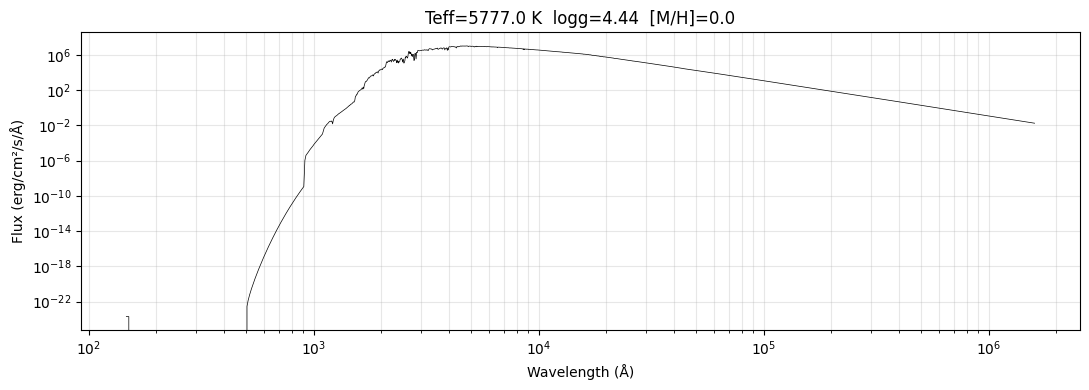

In [4]:
if 'spectrum' in locals():
    fig, ax = plt.subplots(figsize=(11, 4))
    ax.plot(spectrum.wl, spectrum.fl, lw=0.5, color='k')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('Wavelength (Å)')
    ax.set_ylabel('Flux (erg/cm²/s/Å)')
    ax.set_title(f'Teff={spectrum.teff} K  logg={spectrum.logg}  [M/H]={spectrum.metallicity}')
    ax.grid(True, alpha=0.3, which='both')
    plt.tight_layout()
    plt.show()

## 4. Comparing Spectra at Different Temperatures

Because the interpolation is done in the flux cube, each call is very fast — the cube only needs to be loaded from disk once.

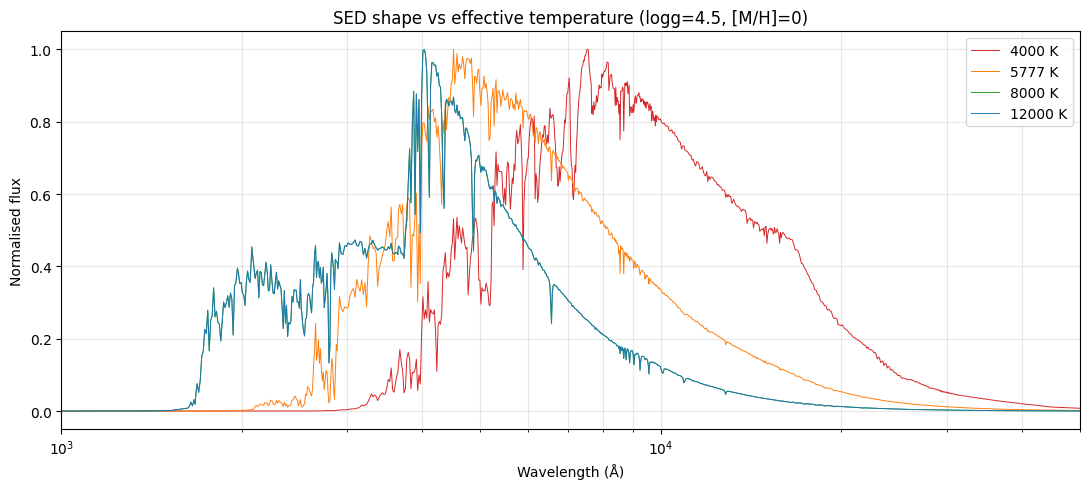

In [5]:
if 'sed' in locals():
    temps = [4000, 5777, 8000, 12000]
    colors = ['#d62728', '#ff7f0e', '#2ca02c', '#1f77b4']

    fig, ax = plt.subplots(figsize=(11, 5))
    for t, col in zip(temps, colors):
        spec = sed(teff=t, logg=4.5, metallicity=0.0)
        # Normalise each spectrum to its own peak for shape comparison
        ax.plot(spec.wl, spec.fl / spec.fl.max(), lw=0.7, color=col, label=f'{t} K')

    ax.set_xscale('log')
    ax.set_xlim(1000, 50000)
    ax.set_xlabel('Wavelength (Å)')
    ax.set_ylabel('Normalised flux')
    ax.set_title('SED shape vs effective temperature (logg=4.5, [M/H]=0)')
    ax.legend()
    ax.grid(True, alpha=0.3, which='both')
    plt.tight_layout()
    plt.show()

## 5. Metallicity Effect

Interpolation works independently along every axis, so exploring metallicity is just as straightforward.

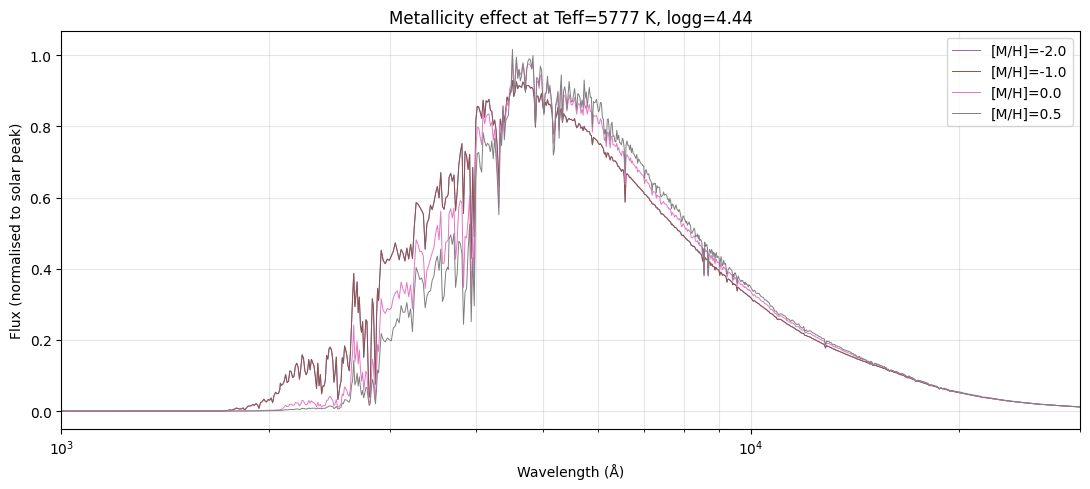

In [6]:
if 'sed' in locals():
    metals = [-2.0, -1.0, 0.0, 0.5]
    colors = ['#9467bd', '#8c564b', '#e377c2', '#7f7f7f']

    fig, ax = plt.subplots(figsize=(11, 5))
    ref = sed(teff=5777, logg=4.44, metallicity=0.0)

    for m, col in zip(metals, colors):
        spec = sed(teff=5777, logg=4.44, metallicity=m)
        ax.plot(spec.wl, spec.fl / ref.fl.max(), lw=0.7, color=col, label=f'[M/H]={m}')

    ax.set_xscale('log')
    ax.set_xlim(1000, 30000)
    ax.set_xlabel('Wavelength (Å)')
    ax.set_ylabel('Flux (normalised to solar peak)')
    ax.set_title('Metallicity effect at Teff=5777 K, logg=4.44')
    ax.legend()
    ax.grid(True, alpha=0.3, which='both')
    plt.tight_layout()
    plt.show()

## 6. Grid Boundaries and `fill_gaps`

By default, parameters outside the grid are clamped to the nearest edge rather than raising an error. You can disable this with `fill_gaps=False` on the model.

In [7]:
if 'sed' in locals():
    ranges = sed.parameter_ranges()
    print("Grid boundaries:")
    for k, (lo, hi) in ranges.items():
        print(f"  {k:12s}: {lo} → {hi}")

    # Parameters slightly outside the grid — clamped by default
    spec_edge = sed(teff=50001, logg=4.5, metallicity=0.0)
    print(f"\nRequested Teff=50001 K, got Teff={spec_edge.teff} K (clamped to grid edge)")

Grid boundaries:
  teff        : 4000.0 → 8000.0
  logg        : 3.0 → 5.0
  metallicity : -1.0 → 0.5

Requested Teff=50001 K, got Teff=8000.0 K (clamped to grid edge)
